# 🔍 Telco Customer Churn Prediction
---
**Objective:** Build a machine learning model to predict which customers are likely to churn (leave the service).  
**Dataset:** [Kaggle - Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  

## 📋 Project Workflow
1. **Import Libraries** – Load all necessary Python packages
2. **Load Data** – Read the dataset and understand its structure
3. **Exploratory Data Analysis (EDA)** – Visualize and understand patterns
4. **Data Cleaning & Preprocessing** – Handle missing values, encode features
5. **Feature Engineering** – Select and transform important features
6. **Model Training** – Train 5 classic ML models
7. **Model Comparison** – Compare accuracy and pick the best
8. **Save Model** – Export the best model as `.pkl` for deployment
---

In [1]:
import joblib, os, warnings, time

In [2]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ============================================================
# STEP 1: Import all required libraries
# ============================================================

import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# --- Machine Learning Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier 
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# --- Evaluation Metrics ---
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score

# --- Save Model ---
import joblib                                # For saving/loading .pkl model files
import warnings
warnings.filterwarnings('ignore')            # Suppress warnings for cleaner output

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [4]:
#STEP 2 LOAD THE DATASET

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'✅ Dataset loaded successfully!')
print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'\nThis means we have {df.shape[0]} customers and {df.shape[1]} attributes about each one.')

✅ Dataset loaded successfully!
Dataset shape: 7043 rows x 21 columns

This means we have 7043 customers and 21 attributes about each one.


In [5]:
df.head(10)# Display the first 10 rows of the dataset to understand its structure and contents.

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [6]:
# Let's see ALL column names and their data types
# 💡 .info() is your best friend — it tells you:
#    - Column names
#    - How many non-null values (helps spot missing data)
#    - Data type of each column (object = text, int64 = whole numbers, float64 = decimals)
print('=' * 60)
print('DATASET INFO')
print('=' * 60)
df.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nu

In [7]:
# Statistical summary of NUMERICAL columns
# 💡 .describe() gives you: count, mean, std, min, 25%, 50%, 75%, max
#    This helps you spot outliers and understand the range of values
print('=' * 60)
print('STATISTICAL SUMMARY (Numerical Columns)')
print('=' * 60)
df.describe()

STATISTICAL SUMMARY (Numerical Columns)


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# Statistical summary of CATEGORICAL columns (text-based)
# 💡 This tells you how many unique values each text column has
#    and which value appears most often (top) and how many times (freq)
print('=' * 60)
print('STATISTICAL SUMMARY (Categorical Columns)')
print('=' * 60)
df.describe(include='object')

STATISTICAL SUMMARY (Categorical Columns)


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


---
## 3️⃣ Exploratory Data Analysis (EDA)

**What is EDA?** It's the detective work of data science — we explore the data visually  
to find patterns, anomalies, and relationships BEFORE building any model.

**Key questions we want to answer:**
- How many customers churned vs stayed?
- Which features are most related to churn?
- Are there any patterns in customer behavior?

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


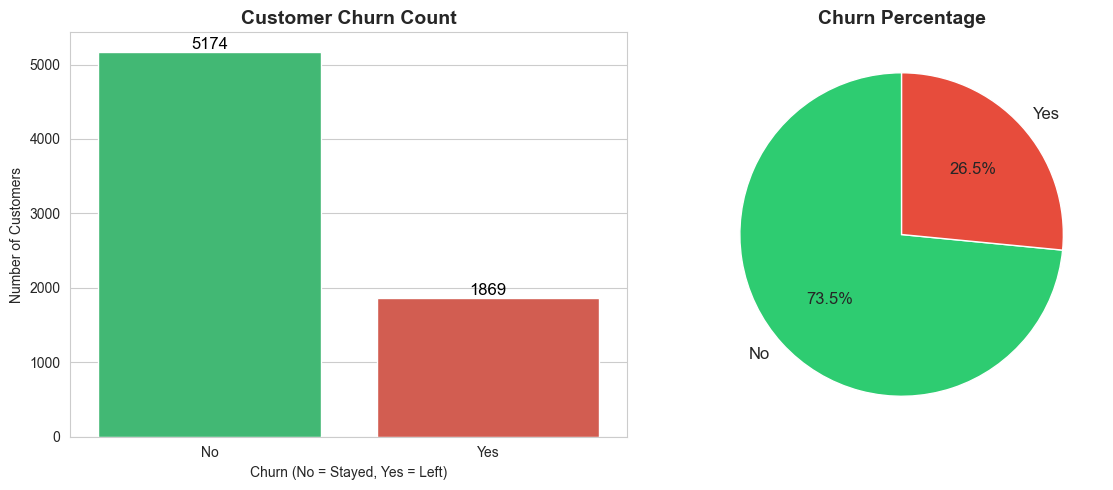


📊 INSIGHT: The dataset is moderately imbalanced (~26% churn rate).
   This is realistic — most customers stay, but a significant portion leaves.


In [9]:
# ============================================================
# 3.1: Target Variable Distribution (Churn)
# ============================================================
# 💡 The 'Churn' column is our TARGET — what we want to predict.
#    Let's see how balanced it is. If it's very imbalanced (e.g., 95% No, 5% Yes),
#    our model might just predict "No" all the time and still look accurate!

print('Churn Distribution:')
print(df['Churn'].value_counts())
print(f'\nChurn rate: {df["Churn"].value_counts(normalize=True)["Yes"]*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Count Plot
colors = ['#2ecc71', '#e74c3c']
sns.countplot(x='Churn', data=df, palette=colors, ax=axes[0])

axes[0].set_title('Customer Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn (No = Stayed, Yes = Left)')
axes[0].set_ylabel('Number of Customers')

#Add count labels on bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                     textcoords='offset points')
    

df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=colors, 
                                      startangle=90, ax=axes[1],
                                      textprops={'fontsize': 12})
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print('\n📊 INSIGHT: The dataset is moderately imbalanced (~26% churn rate).')
print('   This is realistic — most customers stay, but a significant portion leaves.')

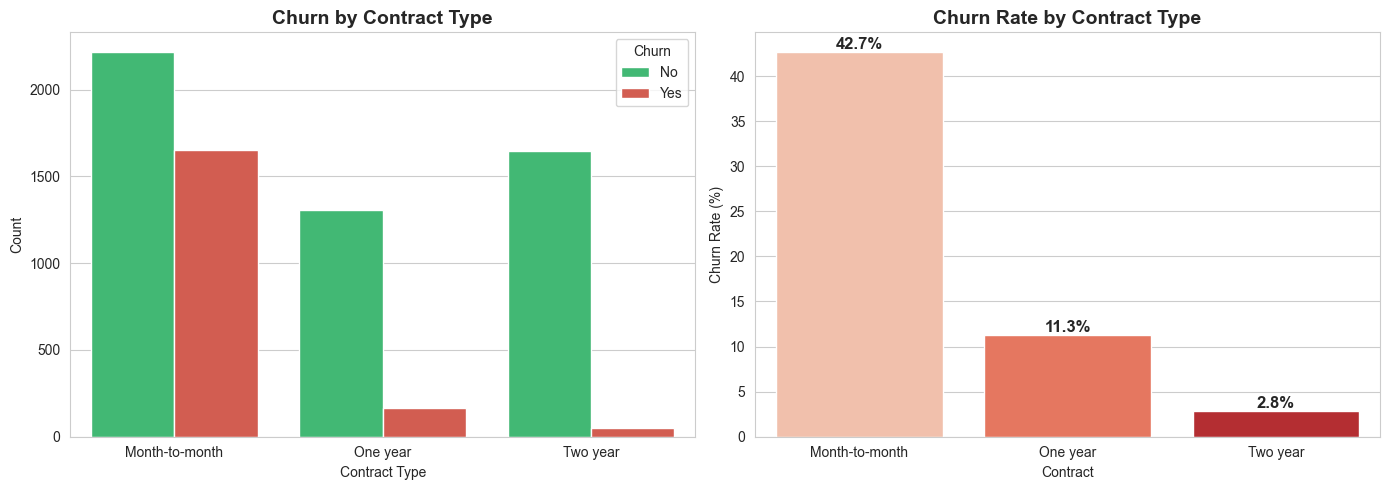

📊 INSIGHT: Month-to-month customers have MUCH higher churn rate!
   This makes sense — they have no long-term commitment binding them.


In [10]:
# 3.2  churn by contract type
# Do Customers on month-to-month contracts churn more?
# (Spoiler: Usually yes! No commitment = easy to leave)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contract type vs Churn
sns.countplot(x='Contract', hue='Churn', data=df, palette=colors, ax=axes[0])
axes[0].set_title('Churn by Contract Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Count')

#Churn Rate By Contract Type
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum()/len(x) * 100
).reset_index()
contract_churn.columns = ['Contract', 'Churn_Rate']
sns.barplot(x='Contract', y='Churn_Rate', data=contract_churn, palette='Reds', ax=axes[1])
axes[1].set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')
    
plt.tight_layout()
plt.show()


print('📊 INSIGHT: Month-to-month customers have MUCH higher churn rate!')
print('   This makes sense — they have no long-term commitment binding them.')

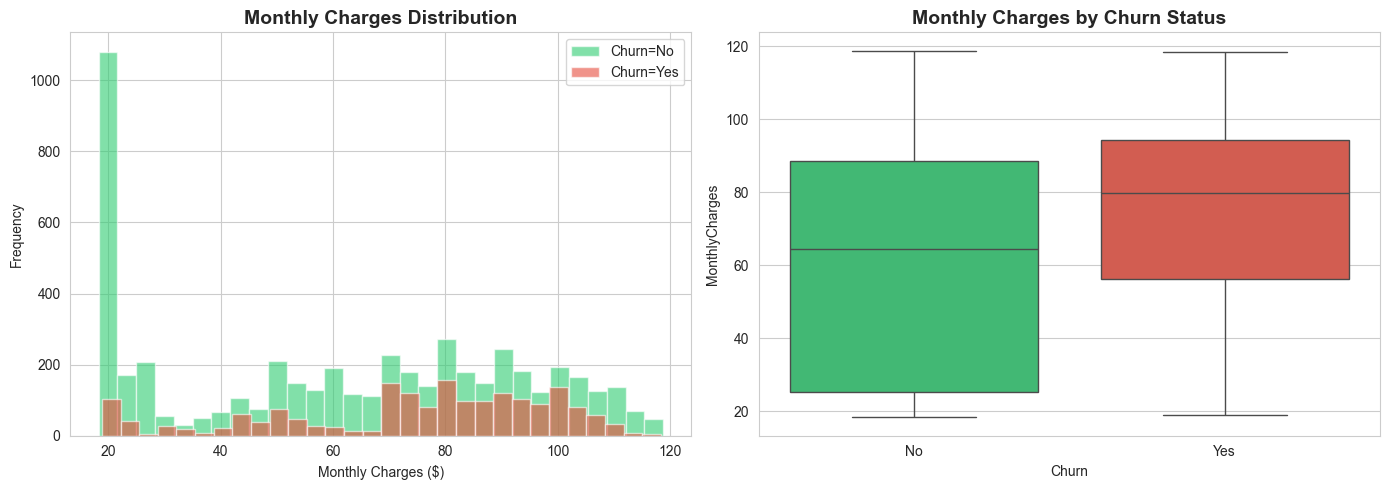

📊 INSIGHT:
   Average monthly charge for churned customers: $74.44
   Average monthly charge for retained customers: $61.27
   Customers who churn tend to have HIGHER monthly charges.


In [11]:
# Do customer who pay more tend to churn more?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for label, color in zip(['No', 'Yes'], colors):
    subset = df[df['Churn'] == label]
    axes[0].hist(subset['MonthlyCharges'], bins=30, alpha=0.6, label=f'Churn={label}', color=color)
axes[0].set_title('Monthly Charges Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=colors, ax=axes[1])
axes[1].set_title('Monthly Charges by Churn Status', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


print(f'📊 INSIGHT:')
print(f'   Average monthly charge for churned customers: ${df[df["Churn"]=="Yes"]["MonthlyCharges"].mean():.2f}')
print(f'   Average monthly charge for retained customers: ${df[df["Churn"]=="No"]["MonthlyCharges"].mean():.2f}')
print(f'   Customers who churn tend to have HIGHER monthly charges.')

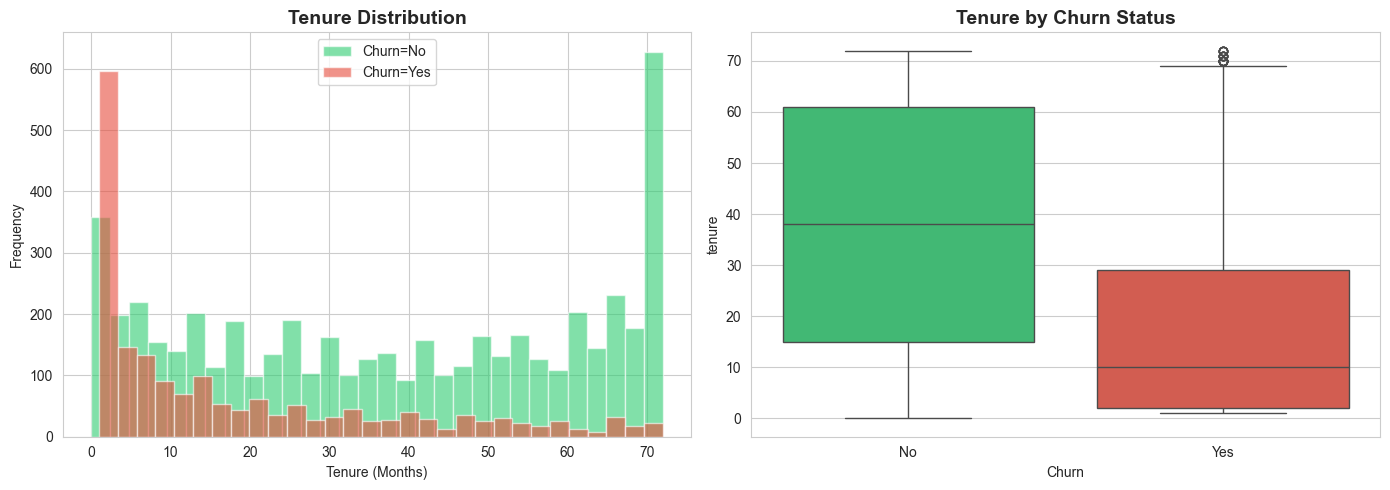

📊 INSIGHT: Newer customers (low tenure) are MUCH more likely to churn.
   Long-term customers are more loyal — they've already committed.


In [12]:
# DO NEWER CUSTOMER CHURN MORE THAN LONG TERM ONES?
fig, axes = plt.subplots(1,2, figsize=(14,5))

#Histogram
for label, color in zip(['No', 'Yes'], colors):
    subset = df[df['Churn'] == label]
    axes[0].hist(subset['tenure'], bins=30, alpha=0.6, label=f'Churn={label}', color=color)
axes[0].set_title('Tenure Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot
sns.boxplot(x='Churn', y='tenure', data=df, palette=colors, ax=axes[1])
axes[1].set_title('Tenure by Churn Status', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('📊 INSIGHT: Newer customers (low tenure) are MUCH more likely to churn.')
print('   Long-term customers are more loyal — they\'ve already committed.')

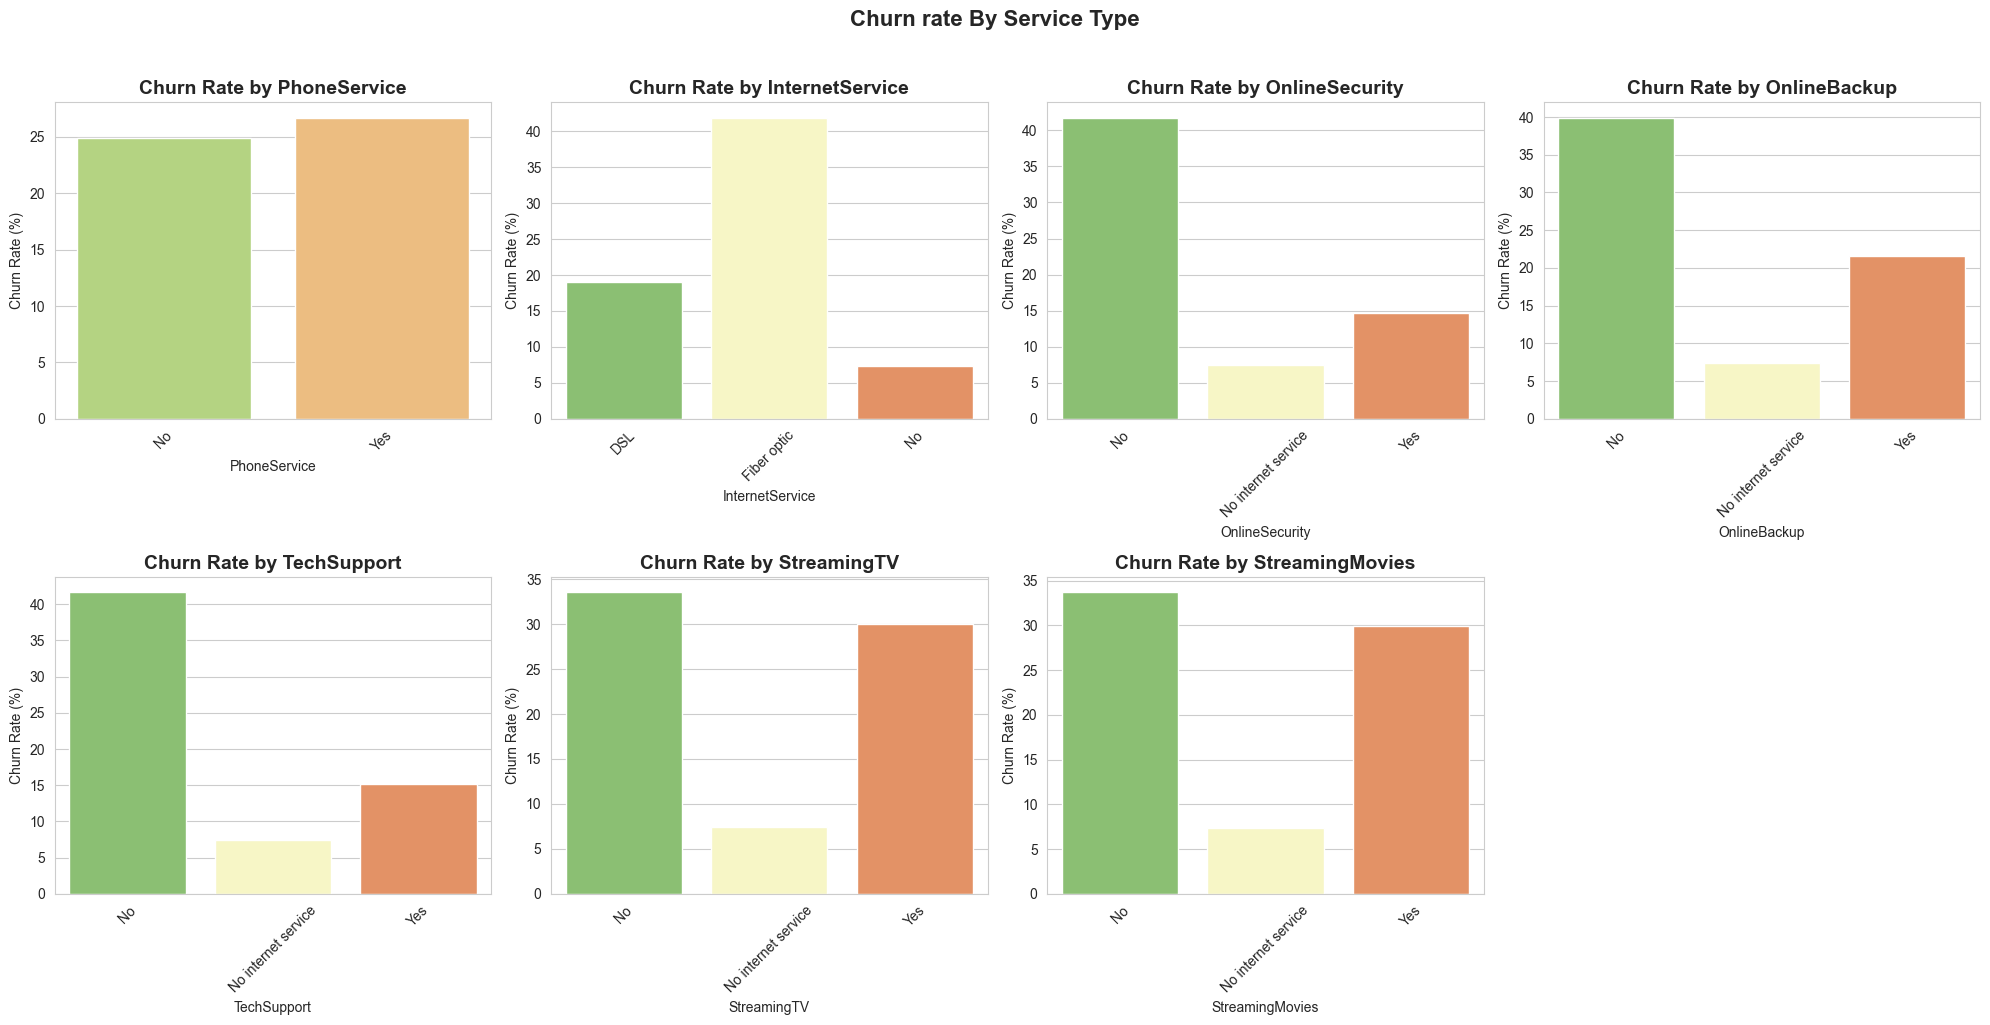

📊 KEY INSIGHTS:
   • Fiber optic internet users have the HIGHEST churn rate
   • Customers WITHOUT OnlineSecurity and TechSupport churn more
   • These protective services act as "stickiness factors"


In [13]:
# LETS CHECK WHICH SERVICES AFFECT CHURN THE MOST

service_cols = ['PhoneService', 'InternetService', 'OnlineSecurity', 
                'OnlineBackup', 'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(2,4, figsize=(20,10))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100).reset_index()
    churn_rate.columns = [col, 'Churn_Rate']

    sns.barplot(x=col, y='Churn_Rate', data=churn_rate, palette='RdYlGn_r', ax=axes[i])
    axes[i].set_title(f'Churn Rate by {col}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=45)

axes[-1].set_visible(False)  # Hide the last empty subplot

plt.suptitle('Churn rate By Service Type', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('📊 KEY INSIGHTS:')
print('   • Fiber optic internet users have the HIGHEST churn rate')
print('   • Customers WITHOUT OnlineSecurity and TechSupport churn more')
print('   • These protective services act as "stickiness factors"')

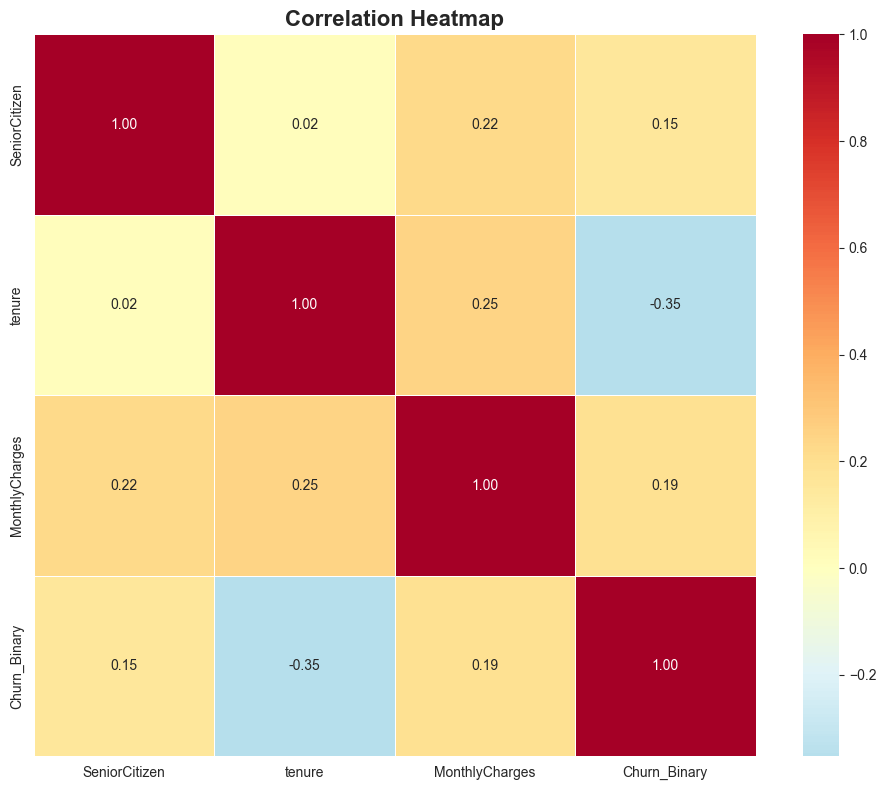

📊 INSIGHT: Look at the Churn_Binary row — it shows which numeric features
   correlate most with churn. Negative correlation with tenure means
   longer tenure = less likely to churn.


In [14]:
# 💡 A heatmap shows how strongly features are related to each other
#    Values close to 1 or -1 = strong relationship
#    Values close to 0 = no relationship

# First , lets create a temporary encoded version for correlation
df_temp = df.copy()
df_temp['Churn_Binary'] = (df_temp['Churn']=='Yes').astype(int)  # Convert 'Yes' to 1 and 'No' to 0

#Select numeric columns
numeric_cols = df_temp.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10, 8))
correlation = df_temp[numeric_cols].corr()
sns.heatmap(correlation, annot=True, cmap='RdYlBu_r', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('📊 INSIGHT: Look at the Churn_Binary row — it shows which numeric features')
print('   correlate most with churn. Negative correlation with tenure means')
print('   longer tenure = less likely to churn.')

del df_temp  # Clean up temporary DataFrame

---
## 4️⃣ Data Cleaning & Preprocessing

**What is Data Cleaning?** Raw data is MESSY — it has missing values, wrong data types,  
and text that machines can't understand. We need to clean it before feeding it to ML models.

**Steps:**
1. Handle missing values
2. Fix data types
3. Remove unnecessary columns
4. Encode categorical variables (convert text → numbers)
5. Scale numerical features

In [15]:
# CHECK FOR MISSING VALUES 

print('=' * 50)
print('MISSING VALUES CHECK')
print('=' * 50)

missing = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percentage})
print(missing_df[missing_df['Missing Count']>0])

if missing.sum() ==0:
    print('\n No missing values found!')



MISSING VALUES CHECK
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

 No missing values found!


In [16]:
# 4.2 Fix Total Charges Column
# 💡 KNOWN ISSUE: TotalCharges is stored as 'object' (text) instead of float
#    This happens because some rows have blank spaces (' ') instead of numbers
#    These are customers with 0 tenure (just joined) — their total charge is empty


print('TotalCharges dtype BEFORE fix:', df['TotalCharges'].dtype)

#FInd the problematic rows
problematic = df[df['TotalCharges'] == ' ']
print(f'\nFound {len(problematic)} rows with blank TotalCharges')
print('These customers have tenure = 0 (just signed up):')
print(problematic[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head())

# Fix: convert to numeric, blanks become NAN, then fill with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

print(f'\nTotalCharges dtype AFTER fix: {df["TotalCharges"].dtype}')
print('✅ TotalCharges cleaned successfully!')


TotalCharges dtype BEFORE fix: object

Found 11 rows with blank TotalCharges
These customers have tenure = 0 (just signed up):
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             

TotalCharges dtype AFTER fix: float64
✅ TotalCharges cleaned successfully!


In [17]:
# ============================================================
# 4.3: Drop Unnecessary Columns
# ============================================================
# 💡 'customerID' is just a unique identifier — it has NO predictive value
#    Keeping it would confuse the model (it would try to find patterns in random IDs)

print('Columns BEFORE dropping:', df.shape[1])
df.drop('customerID', axis=1, inplace=True)
print('Columns AFTER dropping customerID:', df.shape[1])
print('\n✅ Removed customerID — it\'s just an identifier, not a feature.')

Columns BEFORE dropping: 21
Columns AFTER dropping customerID: 20

✅ Removed customerID — it's just an identifier, not a feature.


In [18]:
# ============================================================
# 4.4: Encode Categorical Variables
# ============================================================
# 💡 ML models only understand NUMBERS, not text!
#    We need to convert categorical columns like 'Yes'/'No' to 1/0
#
#    TWO approaches:
#    a) Label Encoding — for binary columns (Yes/No, Male/Female)
#    b) One-Hot Encoding — for columns with 3+ categories
#       (creates separate 0/1 columns for each category)

# Let's see all unique values for each categorical column

print('=' * 60)
print('UNIQUE VALUES IN CATEGORICAL COLUMNS')
print('=' * 60)

for col in df.select_dtypes(include='object').columns:
    print(f'{col}: {df[col].unique()}')
    print()

UNIQUE VALUES IN CATEGORICAL COLUMNS
gender: ['Female' 'Male']

Partner: ['Yes' 'No']

Dependents: ['No' 'Yes']

PhoneService: ['No' 'Yes']

MultipleLines: ['No phone service' 'No' 'Yes']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['No' 'Yes' 'No internet service']

StreamingTV: ['No' 'Yes' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['Month-to-month' 'One year' 'Two year']

PaperlessBilling: ['Yes' 'No']

PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn: ['No' 'Yes']



In [19]:
# ============================================================
# 4.5: Apply Encoding
# ============================================================

# --- STEP A: Label Encode binary columns (Yes/No → 1/0) ---
# These columns only have 2 unique values

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

label_encoder = LabelEncoder()

for col in binary_cols:
    df[col] = label_encoder.fit_transform(df[col])
    print(f'✅ Encoded {col}: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}')
print()

# --- STEP B: One-Hot Encode multi-category columns ---
# These columns have 3+ categories — we can't just assign 1, 2, 3
# because the model would think 3 > 2 > 1 (implying an order that doesn't exist)
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                  'OnlineBackup', 'DeviceProtection', 'TechSupport',
                  'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

print('Columns BEFORE one-hot encoding:', df.shape[1])

# pd.get_dummies creates new binary columns for each category
# drop_first=True removes one column to avoid multicollinearity
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

print(f'Columns AFTER one-hot encoding: {df.shape[1]}')
print('\n✅ All categorical variables encoded!')

✅ Encoded gender: {'Female': np.int64(0), 'Male': np.int64(1)}
✅ Encoded Partner: {'No': np.int64(0), 'Yes': np.int64(1)}
✅ Encoded Dependents: {'No': np.int64(0), 'Yes': np.int64(1)}
✅ Encoded PhoneService: {'No': np.int64(0), 'Yes': np.int64(1)}
✅ Encoded PaperlessBilling: {'No': np.int64(0), 'Yes': np.int64(1)}
✅ Encoded Churn: {'No': np.int64(0), 'Yes': np.int64(1)}

Columns BEFORE one-hot encoding: 20
Columns AFTER one-hot encoding: 31

✅ All categorical variables encoded!


In [20]:
# Let's see what our cleaned DataFrame looks like now
print('=' * 60)
print('CLEANED DATASET PREVIEW')
print('=' * 60)
print(f'Shape: {df.shape}')
print(f'\nAll dtypes are now numeric:')
print(df.dtypes.value_counts())
print()
df.head()

CLEANED DATASET PREVIEW
Shape: (7043, 31)

All dtypes are now numeric:
bool       21
int64       8
float64     2
Name: count, dtype: int64



,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


---
## 5️⃣ Feature Engineering & Preparation

**What?** Prepare the features (X) and target (y), split into train/test sets,  
and scale the numerical features.

**Why scale?**  
- `tenure` ranges from 0-72 months  
- `MonthlyCharges` ranges from \$18-\$118  
- `TotalCharges` ranges from \$0-\$8,684  

Without scaling, the model thinks TotalCharges is MORE IMPORTANT just because  
its numbers are bigger. Scaling puts all features on the same level playing field.

In [21]:
# ============================================================
# 5.1: Split Features (X) and Target (y)
# ============================================================
# 💡 X = all columns EXCEPT Churn (these are the inputs/features)
#    y = only the Churn column (this is what we want to predict)

X = df.drop('Churn', axis=1)
y = df['Churn']

print(f'Features (X) shape: {X.shape} -> {X.shape[0]} customers, {X.shape[1]} features')
print(f'Target (y) shape: {y.shape} -> {y.shape[0]} labels (0 or 1)')
print(f'\nFeature names ({X.shape[1]} total):')
print(list(X.columns))

Features (X) shape: (7043, 30) -> 7043 customers, 30 features
Target (y) shape: (7043,) -> 7043 labels (0 or 1)

Feature names (30 total):
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [22]:
# ============================================================
# 5.2: Train-Test Split
# ============================================================
# 💡 WHY SPLIT? We train the model on 80% of data, then test on 20% it has NEVER seen.
#    This tells us how well the model generalizes to NEW customers.
#    
#    random_state=42 → ensures you get the SAME split every time you run this
#    stratify=y → ensures both train and test sets have the same churn ratio

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 20% for testing
    random_state=42,      # Reproducibility
    stratify=y            # Keep churn ratio consistent
)

print(f'Training set: {X_train.shape[0]} customers ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Testing set:  {X_test.shape[0]} customers ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nChurn distribution in train: {y_train.mean()*100:.1f}%')
print(f'Churn distribution in test:  {y_test.mean()*100:.1f}%')
print('\n✅ Stratified split successful — churn ratios are balanced!')

Training set: 5634 customers (80%)
Testing set:  1409 customers (20%)

Churn distribution in train: 26.5%
Churn distribution in test:  26.5%

✅ Stratified split successful — churn ratios are balanced!


In [23]:
# ============================================================
# 5.3: Feature Scaling (Standardization)
# ============================================================
# 💡 StandardScaler transforms each feature to have:
#    Mean = 0, Standard Deviation = 1
#    Formula: z = (x - mean) / std
#
#    IMPORTANT: Fit the scaler on TRAINING data only, then transform both!
#    If we fit on all data, the model would "peek" at test data (data leakage)

scaler = StandardScaler()

#fit on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Convert back to DataFrame for readibility
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print('Before scaling (first row):')
print(X_train.iloc[0][:5].to_dict())
print(f'\nAfter scaling (first row):')
print(X_train_scaled.iloc[0][:5].to_dict())
print('\n✅ Features scaled successfully!')

Before scaling (first row):
{'gender': 1, 'SeniorCitizen': 0, 'Partner': 0, 'Dependents': 0, 'tenure': 35}

After scaling (first row):
{'gender': 0.9943362376363841, 'SeniorCitizen': -0.44177295439277764, 'Partner': -0.9692341317067846, 'Dependents': -0.6515565336648191, 'tenure': 0.1023712383613841}

✅ Features scaled successfully!


---
## 🧰 Helper — Reusable Evaluation Function

We define this **once** and call it for every model. This is how real data scientists avoid repeating code.

### 📖 Metrics Explainer

| Metric | Question It Answers | Example |
|--------|--------------------|---------|
| **Accuracy** | Overall, how many predictions were correct? | 80 out of 100 correct → 80% |
| **Precision** | When I predict "churn", how often am I right? | Predicted 30 churns, 25 were real → 83% |
| **Recall** | Of all actual churners, how many did I catch? | 40 real churners, caught 25 → 62% |
| **F1-Score** | Balance between Precision & Recall | Harmonic mean — punishes extremes |

In [24]:
# ============================================================
# HELPER: evaluate_model() — reused for all 5 models
# ============================================================
import time 


all_results ={}

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    
    print(f'{"="*65}')
    print(f'  🔄 TRAINING: {name}')
    print(f'{"="*65}')

    # TRAIN
    start =time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    print(f'  ⏱️  Training time: {train_time:.2f} seconds')

    # PREDICTION
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:,1]

    # METRICS
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    print(f'\n  📊 EVALUATION RESULTS:')
    print(f'  ┌──────────────────┬────────────┐')
    print(f'  │ Accuracy         │  {accuracy*100:6.2f}%   │')
    print(f'  │ Precision        │  {precision*100:6.2f}%   │')
    print(f'  │ Recall           │  {recall*100:6.2f}%   │')
    print(f'  │ F1-Score         │  {f1*100:6.2f}%   │')
    print(f'  │ ROC-AUC          │  {auc:.4f}    │')
    print(f'  └──────────────────┴────────────┘')

    print(f'\n  📋 Full Classification Report:')
    print(classification_report(y_test, y_pred, target_names=['Stay (0)', 'Churn (1)']))

    # --- PLOTS ---
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp =cm.ravel()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot = True, fmt='d', cmap='Blues', 
                xticklabels=['Stay', 'Churn'], yticklabels=['Stay','Churn'],
                annot_kws = {'size': 16}, ax=axes[0])
    axes[0].set_xlabel('Predicted', fontsize=12)
    axes[0].set_ylabel('Actual', fontsize=12)
    axes[0].set_title(f'Confusion Matrix - {name}', fontsize=14, fontweight='bold')

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    axes[1].plot(fpr, tpr, color='#3498db', linewidth=2, label=f'AUC = {auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Guess')
    axes[1].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve — {name}', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=11)

    plt.tight_layout()
    plt.show()

    print(f'  Breakdown: TN={tn} | FP={fp} | FN={fn} | TP={tp}')
    print(f'  ✅ Correctly caught {tp} out of {tp+fn} actual churners')
    print(f'  ❌ Missed {fn} churners (False Negatives)')

    # --- STORE ---
    all_results[name] = {
        'model': model, 'accuracy': accuracy, 'precision': precision,
        'recall': recall, 'f1_score': f1, 'roc_auc': auc,
        'train_time': train_time, 'y_pred': y_pred, 'y_pred_proba': y_pred_proba
    }
    return all_results[name]

print('✅ evaluate_model() function ready!')
print('   Now we train each model one by one below ⬇️')

✅ evaluate_model() function ready!
   Now we train each model one by one below ⬇️


---
## 6️⃣ Model 1 — Logistic Regression

### 🧠 How It Works
Draws a **straight line** (hyperplane) to separate churners from non-churners.  
Outputs a probability (0 to 1) — if > 0.5, predict Churn.

| Pros | Cons |
|------|------|
| Very fast to train | Assumes linear relationship |
| Easy to interpret | May underperform on complex patterns |
| Great baseline model | Sensitive to outliers |

  🔄 TRAINING: Logistic Regression
  ⏱️  Training time: 0.03 seconds

  📊 EVALUATION RESULTS:
  ┌──────────────────┬────────────┐
  │ Accuracy         │   80.70%   │
  │ Precision        │   65.84%   │
  │ Recall           │   56.68%   │
  │ F1-Score         │   60.92%   │
  │ ROC-AUC          │  0.8418    │
  └──────────────────┴────────────┘

  📋 Full Classification Report:
              precision    recall  f1-score   support

    Stay (0)       0.85      0.89      0.87      1035
   Churn (1)       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



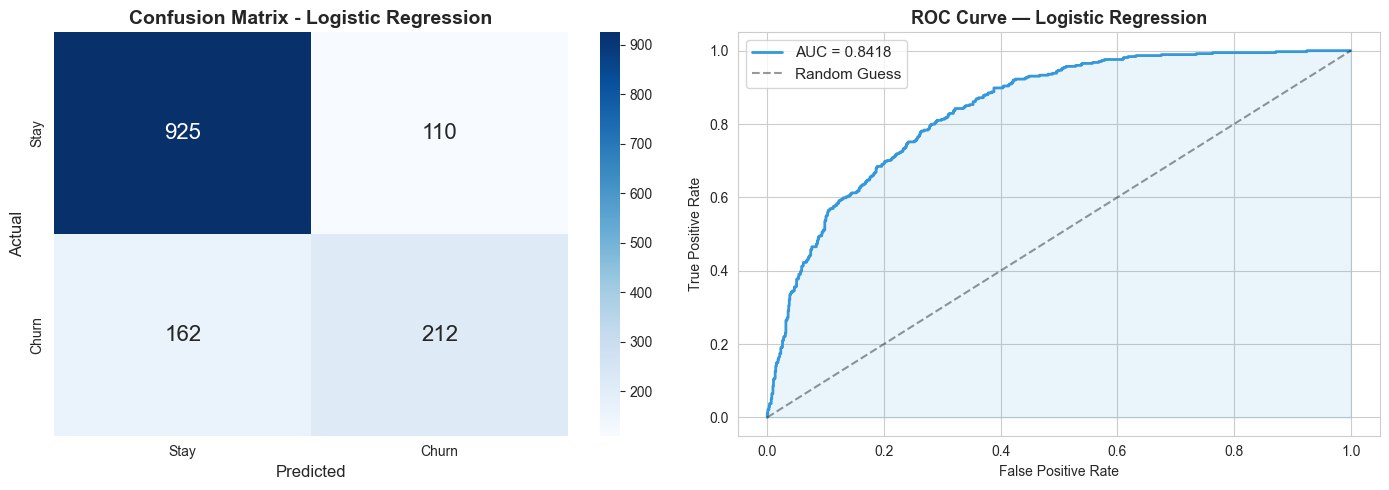

  Breakdown: TN=925 | FP=110 | FN=162 | TP=212
  ✅ Correctly caught 212 out of 374 actual churners
  ❌ Missed 162 churners (False Negatives)


In [25]:
# ============================================================
# MODEL 1: Logistic Regression
# ============================================================

lr_model = LogisticRegression(
    max_iter=1000,       # Max iterations to converge
    random_state=42,
    solver='lbfgs'       # Optimization algorithm
)

lr_result = evaluate_model(
    'Logistic Regression', lr_model,
    X_train_scaled, y_train, X_test_scaled, y_test
)

---
## 7️⃣ Model 2 — Random Forest

### 🧠 How It Works
Builds **200 decision trees**, each trained on a random subset of data.  
Each tree votes — the **majority wins**. Like asking 200 experts.

| Pros | Cons |
|------|------|
| Handles non-linear patterns | Slower to train |
| Resistant to overfitting | Harder to interpret |
| Shows feature importance | Can struggle with imbalance |

  🔄 TRAINING: Random Forest
  ⏱️  Training time: 0.81 seconds

  📊 EVALUATION RESULTS:
  ┌──────────────────┬────────────┐
  │ Accuracy         │   80.20%   │
  │ Precision        │   66.32%   │
  │ Recall           │   51.60%   │
  │ F1-Score         │   58.05%   │
  │ ROC-AUC          │  0.8425    │
  └──────────────────┴────────────┘

  📋 Full Classification Report:
              precision    recall  f1-score   support

    Stay (0)       0.84      0.91      0.87      1035
   Churn (1)       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



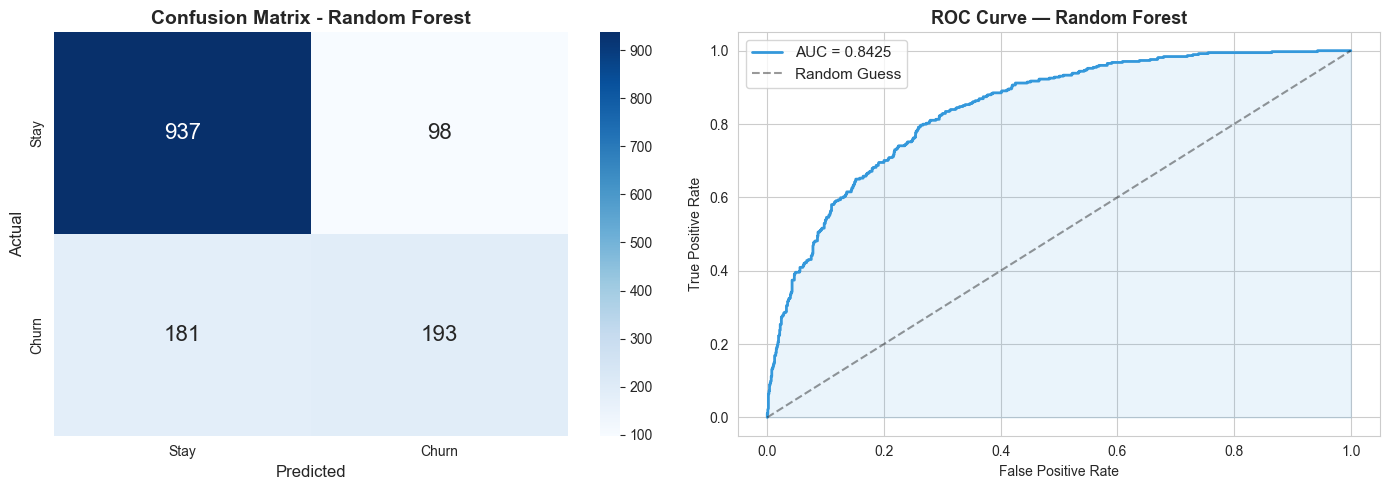

  Breakdown: TN=937 | FP=98 | FN=181 | TP=193
  ✅ Correctly caught 193 out of 374 actual churners
  ❌ Missed 181 churners (False Negatives)


In [26]:
rf_model = RandomForestClassifier(
    n_estimators=200, # Number of trees
    max_depth=10,      # Max depth per tree
    min_samples_split=5,
    random_state=42
)

rf_result = evaluate_model(
    'Random Forest', rf_model,
    X_train_scaled, y_train, X_test_scaled, y_test
)

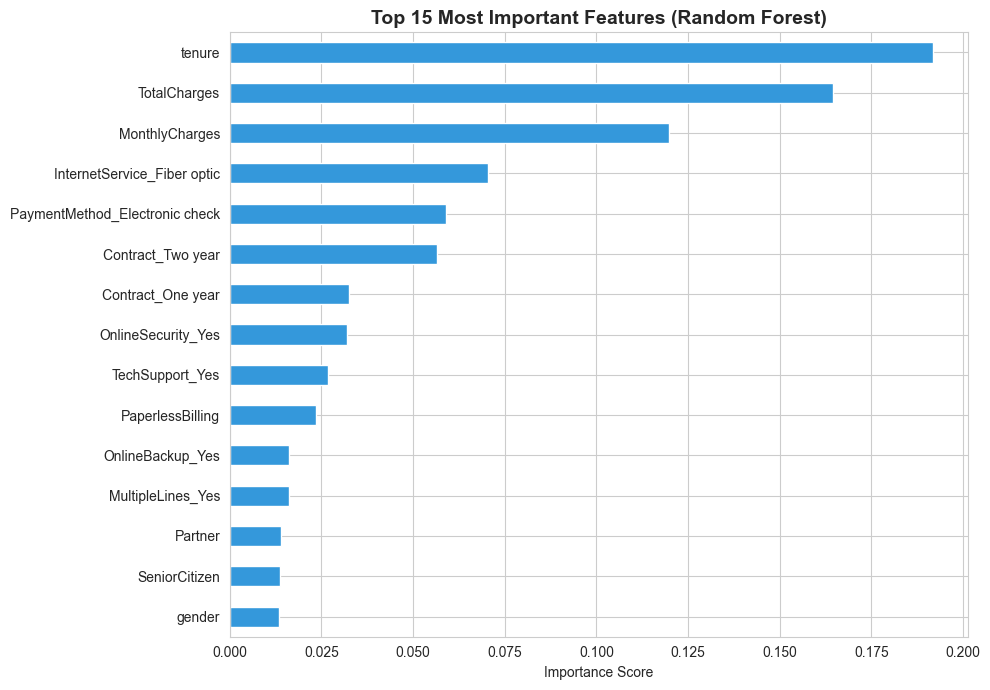

📊 Top 5 features driving churn prediction:
   1. tenure — 0.1919
   2. TotalCharges — 0.1646
   3. MonthlyCharges — 0.1199
   4. InternetService_Fiber optic — 0.0706
   5. PaymentMethod_Electronic check — 0.0589


In [27]:
# BONUS: Feature Importance from Random Forest
top_15 = pd.Series(rf_model.feature_importances_, index=X.columns).nlargest(15)

plt.figure(figsize=(10, 7))
top_15.sort_values().plot(kind='barh', color='#3498db', edgecolor='white')
plt.title('Top 15 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('📊 Top 5 features driving churn prediction:')
for i, (f, v) in enumerate(top_15.nlargest(5).items(), 1):
    print(f'   {i}. {f} — {v:.4f}')

---
## 8️⃣ Model 3 — Gradient Boosting

### 🧠 How It Works
Builds trees **sequentially** — each new tree fixes the mistakes of the previous one.  
Tree 1 makes errors → Tree 2 focuses on those errors → Tree 3 fixes what remains → ...

| Pros | Cons |
|------|------|
| Often **best accuracy** among classic ML | Slowest to train |
| Handles complex patterns | Prone to overfitting |
| Built-in feature importance | More hyperparameters to tune |

  🔄 TRAINING: Gradient Boosting
  ⏱️  Training time: 2.39 seconds

  📊 EVALUATION RESULTS:
  ┌──────────────────┬────────────┐
  │ Accuracy         │   78.92%   │
  │ Precision        │   62.30%   │
  │ Recall           │   52.14%   │
  │ F1-Score         │   56.77%   │
  │ ROC-AUC          │  0.8296    │
  └──────────────────┴────────────┘

  📋 Full Classification Report:
              precision    recall  f1-score   support

    Stay (0)       0.84      0.89      0.86      1035
   Churn (1)       0.62      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



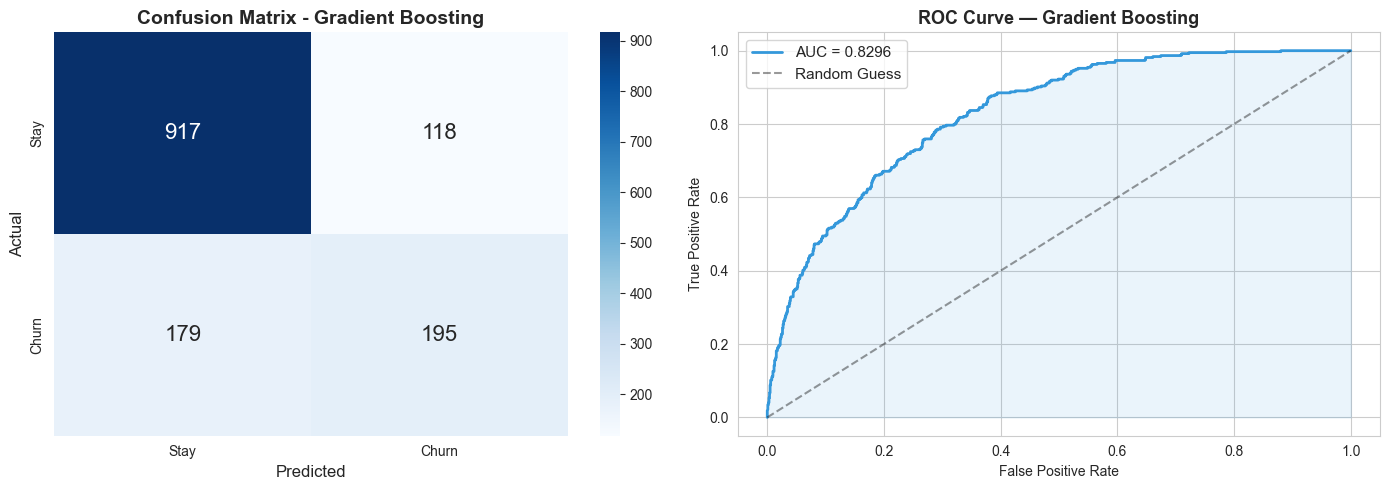

  Breakdown: TN=917 | FP=118 | FN=179 | TP=195
  ✅ Correctly caught 195 out of 374 actual churners
  ❌ Missed 179 churners (False Negatives)


In [28]:
# MODEL 3: Gradient Boosting

gb_model = GradientBoostingClassifier(
    n_estimators=200,  # Number of boosting stages
    learning_rate=0.1, # Step size shrinkage
    max_depth=5,       # Max depth of each tree
    subsample=0.8,     # Use 80% of data for each tree (stochastic boosting)
    random_state=42
)

gb_result = evaluate_model(
    'Gradient Boosting', gb_model,
    X_train_scaled, y_train, X_test_scaled, y_test
)

---
## 9️⃣ Model 4 — Support Vector Machine (SVM)

### 🧠 How It Works
Finds the **best boundary** with the **maximum margin** between classes.  
The RBF kernel handles non-linear boundaries by projecting data into higher dimensions.

| Pros | Cons |
|------|------|
| Effective in high dimensions | Slow on large datasets |
| Works well with clear margins | Very sensitive to scaling |
| Memory efficient | Hard to interpret (black box) |

  🔄 TRAINING: SVM (RBF Kernel)
  ⏱️  Training time: 4.65 seconds

  📊 EVALUATION RESULTS:
  ┌──────────────────┬────────────┐
  │ Accuracy         │   79.28%   │
  │ Precision        │   64.44%   │
  │ Recall           │   48.93%   │
  │ F1-Score         │   55.62%   │
  │ ROC-AUC          │  0.7961    │
  └──────────────────┴────────────┘

  📋 Full Classification Report:
              precision    recall  f1-score   support

    Stay (0)       0.83      0.90      0.86      1035
   Churn (1)       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



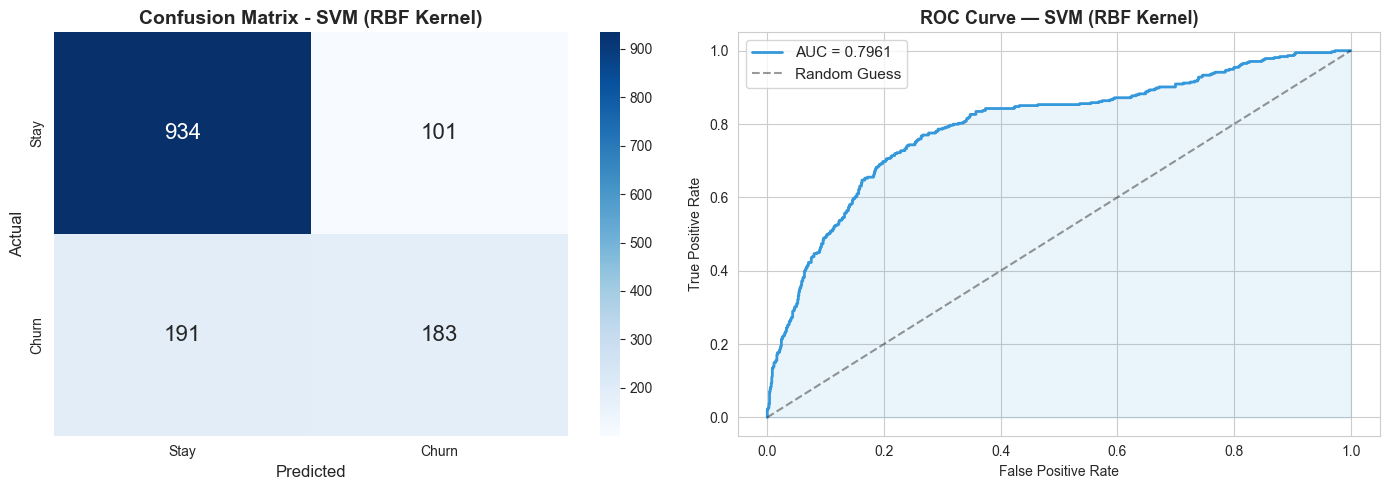

  Breakdown: TN=934 | FP=101 | FN=191 | TP=183
  ✅ Correctly caught 183 out of 374 actual churners
  ❌ Missed 191 churners (False Negatives)


In [29]:
# MODEL 4: Support vector Machine (SVM)

svm_model = SVC(
    kernel='rbf',        # Radial Basis Function kernel
    C=1.0,               # Regularization strength
    gamma='scale',       # Kernel coefficient
    probability=True,    # Enable probability estimates
    random_state=42
)

svm_result = evaluate_model(
    'SVM (RBF Kernel)', svm_model,
    X_train_scaled, y_train, X_test_scaled, y_test
)

---
## 🔟 Model 5 — K-Nearest Neighbors (KNN)

### 🧠 How It Works
Doesn't actually "learn" — it **memorizes** all training data.  
For a new customer, it finds the **5 most similar** customers and predicts based on majority.

| Pros | Cons |
|------|------|
| Super simple to understand | Slow at prediction time |
| No training phase needed | Very sensitive to scaling |
| Good for small datasets | Struggles in high dimensions |

  🔄 TRAINING: KNN (K=5)
  ⏱️  Training time: 0.00 seconds

  📊 EVALUATION RESULTS:
  ┌──────────────────┬────────────┐
  │ Accuracy         │   74.73%   │
  │ Precision        │   52.53%   │
  │ Recall           │   50.00%   │
  │ F1-Score         │   51.23%   │
  │ ROC-AUC          │  0.7716    │
  └──────────────────┴────────────┘

  📋 Full Classification Report:
              precision    recall  f1-score   support

    Stay (0)       0.82      0.84      0.83      1035
   Churn (1)       0.53      0.50      0.51       374

    accuracy                           0.75      1409
   macro avg       0.67      0.67      0.67      1409
weighted avg       0.74      0.75      0.75      1409



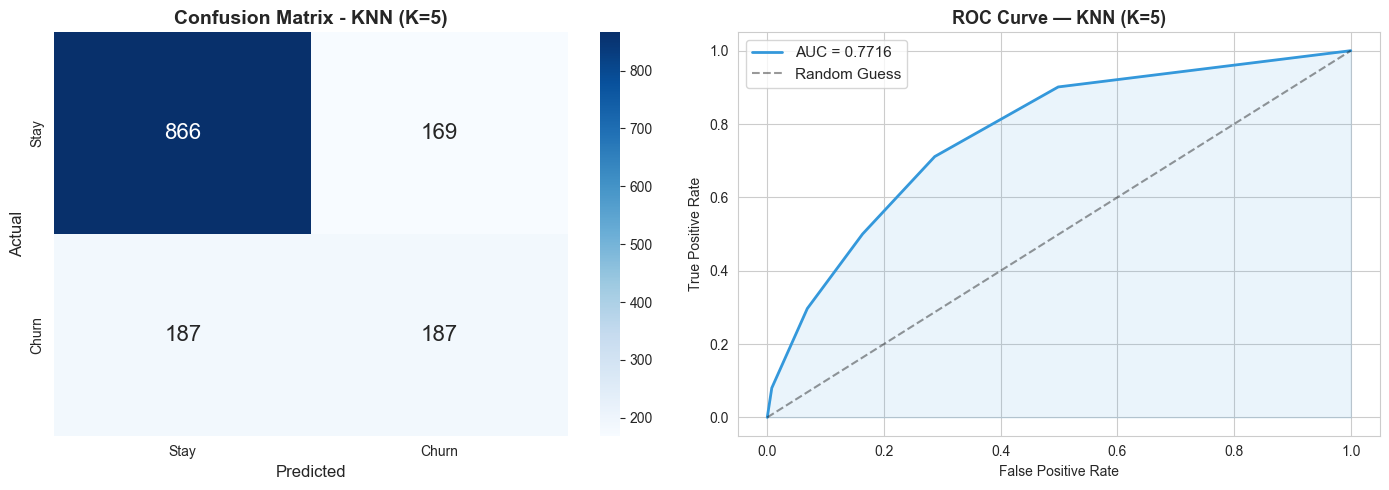

  Breakdown: TN=866 | FP=169 | FN=187 | TP=187
  ✅ Correctly caught 187 out of 374 actual churners
  ❌ Missed 187 churners (False Negatives)


In [30]:
# ============================================================
# MODEL 5: K-Nearest Neighbors
# ============================================================

knn_model = KNeighborsClassifier(
    n_neighbors=5,       # Check 5 nearest neighbors
    weights='uniform',   # Equal vote for all neighbors
    metric='minkowski',  # Distance metric
    p=2                  # p=2 = Euclidean distance
)

knn_result = evaluate_model(
    'KNN (K=5)', knn_model,
    X_train_scaled, y_train, X_test_scaled, y_test
)

---
## 1️⃣1️⃣ Final Comparison — All 5 Models Side by Side

The moment of truth — which model is the **champion**?

In [31]:
#11.1 Comparison Table

comparison_df = pd.DataFrame({
    'Model': list(all_results.keys()),
    'Accuracy': [all_results[m]['accuracy']*100 for m in all_results],
    'Precision': [all_results[m]['precision']*100 for m in all_results],
    'Recall': [all_results[m]['recall']*100 for m in all_results],
    'F1-Score': [all_results[m]['f1_score']*100 for m in all_results],
    'ROC-AUC': [all_results[m]['roc_auc'] for m in all_results],
    'Train Time': [f"{all_results[m]['train_time']:.2f}s" for m in all_results],
}).sort_values('F1-Score', ascending=False).reset_index(drop=True)

comparison_df.index += 1  # Start index at 1 for better readability
comparison_df.index.name = 'Rank'


print('=' * 95)
print('📊 FINAL MODEL COMPARISON (Ranked by F1-Score)')
print('=' * 95)
print(comparison_df.to_string())

best_name = comparison_df.iloc[0]['Model']
print(f'\n🏆 WINNER: {best_name}')
print(f'   Accuracy:  {comparison_df.iloc[0]["Accuracy"]:.2f}%')
print(f'   Precision: {comparison_df.iloc[0]["Precision"]:.2f}%')
print(f'   Recall:    {comparison_df.iloc[0]["Recall"]:.2f}%')
print(f'   F1-Score:  {comparison_df.iloc[0]["F1-Score"]:.2f}%')
print(f'   ROC-AUC:   {comparison_df.iloc[0]["ROC-AUC"]:.2f}%')
print(f'   Train Time: {comparison_df.iloc[0]["Train Time"]}')

📊 FINAL MODEL COMPARISON (Ranked by F1-Score)
                    Model   Accuracy  Precision     Recall   F1-Score   ROC-AUC Train Time
Rank                                                                                      
1     Logistic Regression  80.695529  65.838509  56.684492  60.919540  0.841778      0.03s
2           Random Forest  80.198722  66.323024  51.604278  58.045113  0.842547      0.81s
3       Gradient Boosting  78.921221  62.300319  52.139037  56.768559  0.829640      2.39s
4        SVM (RBF Kernel)  79.276082  64.436620  48.930481  55.623100  0.796125      4.65s
5               KNN (K=5)  74.733854  52.528090  50.000000  51.232877  0.771625      0.00s

🏆 WINNER: Logistic Regression
   Accuracy:  80.70%
   Precision: 65.84%
   Recall:    56.68%
   F1-Score:  60.92%
   ROC-AUC:   0.84%
   Train Time: 0.03s


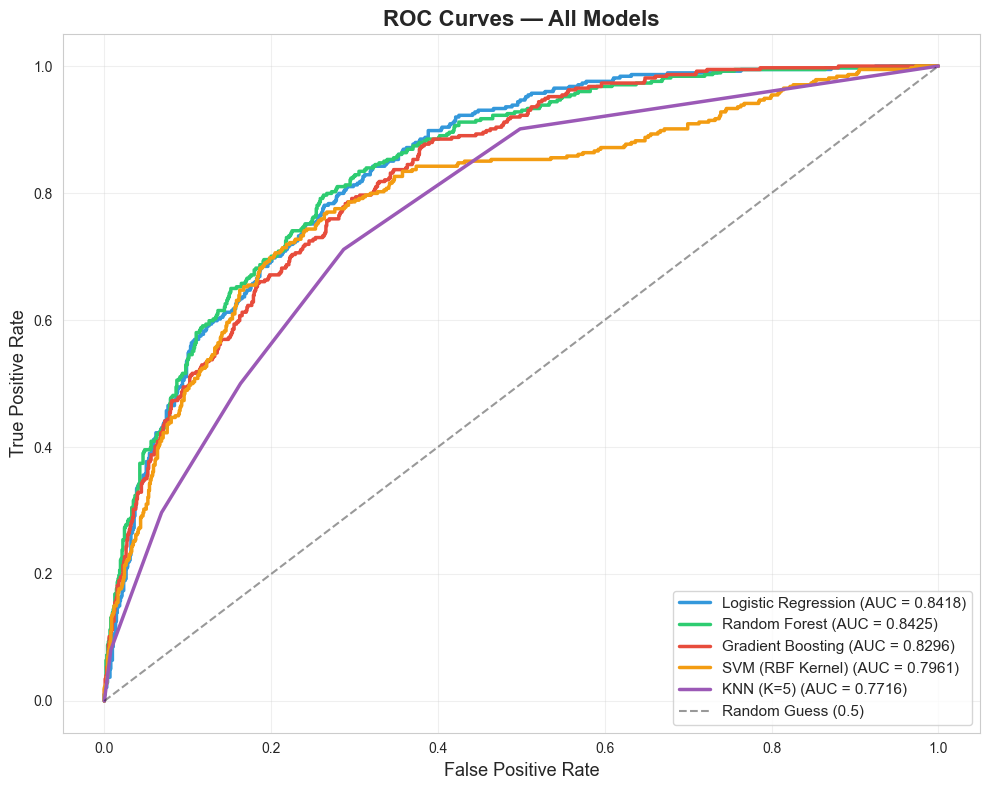

In [33]:
# ============================================================
# 11.3: ROC Curves — All Models Together
# ============================================================

bar_colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

plt.figure(figsize=(10, 8))
for i, (name, result) in enumerate(all_results.items()):
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
    plt.plot(fpr, tpr, color=bar_colors[i], linewidth=2.5,
             label=f'{name} (AUC = {result["roc_auc"]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=1.5, label='Random Guess (0.5)')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curves — All Models', fontsize=16, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

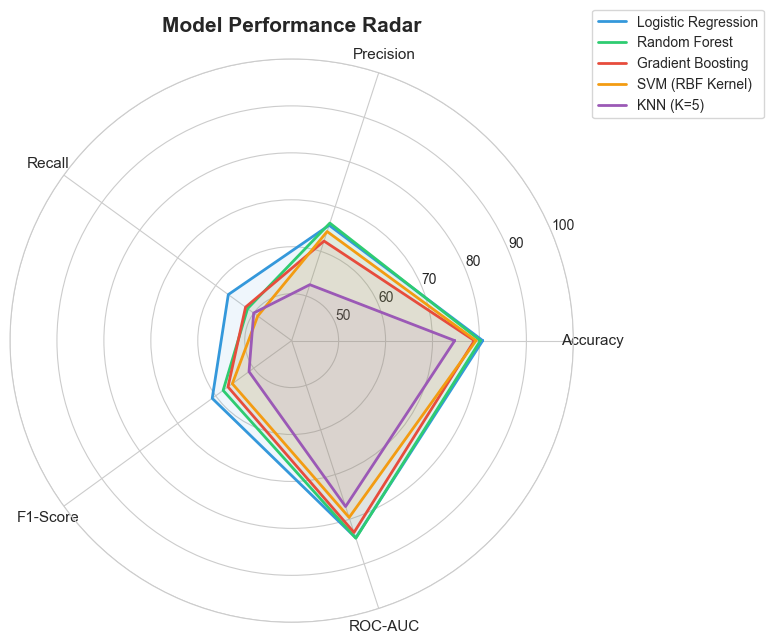

In [34]:
# ============================================================
# 11.4: Radar Chart — Multi-Metric Overview
# ============================================================

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i, (name, result) in enumerate(all_results.items()):
    values = [result['accuracy']*100, result['precision']*100,
              result['recall']*100, result['f1_score']*100, result['roc_auc']*100]
    values += values[:1]
    ax.plot(angles, values, color=bar_colors[i], linewidth=2, label=name)
    ax.fill(angles, values, color=bar_colors[i], alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(40, 100)
ax.set_title('Model Performance Radar', fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# 11.5: Final Verdict
# ============================================================

print('\n' + '=' * 70)
print('🏆 FINAL VERDICT — Best Model Per Metric')
print('=' * 70)

for key, label in [('accuracy','Accuracy'), ('precision','Precision'),
                    ('recall','Recall'), ('f1_score','F1-Score'), ('roc_auc','ROC-AUC')]:
    best = max(all_results.items(), key=lambda x: x[1][key])
    print(f'  🥇 Best {label:10s}: {best[0]:25s} → {best[1][key]*100:.2f}%')

overall_best_name = max(all_results, key=lambda x: all_results[x]['f1_score'])
ob = all_results[overall_best_name]

print(f'\n{"="*70}')
print(f'  🎯 RECOMMENDED MODEL: {overall_best_name}')
print(f'     (Selected by highest F1-Score — best balance of Precision & Recall)')
print(f'\n     Accuracy:  {ob["accuracy"]*100:.2f}%')
print(f'     Precision: {ob["precision"]*100:.2f}%')
print(f'     Recall:    {ob["recall"]*100:.2f}%')
print(f'     F1-Score:  {ob["f1_score"]*100:.2f}%')
print(f'     ROC-AUC:   {ob["roc_auc"]:.4f}')
print(f'{"="*70}')


🏆 FINAL VERDICT — Best Model Per Metric
  🥇 Best Accuracy  : Logistic Regression       → 80.70%
  🥇 Best Precision : Random Forest             → 66.32%
  🥇 Best Recall    : Logistic Regression       → 56.68%
  🥇 Best F1-Score  : Logistic Regression       → 60.92%
  🥇 Best ROC-AUC   : Random Forest             → 84.25%

  🎯 RECOMMENDED MODEL: Logistic Regression
     (Selected by highest F1-Score — best balance of Precision & Recall)

     Accuracy:  80.70%
     Precision: 65.84%
     Recall:    56.68%
     F1-Score:  60.92%
     ROC-AUC:   0.8418


---
## 1️⃣2️⃣ Save Best Model as .pkl

In [36]:
# ============================================================
# 12.1: Save model + scaler + feature names
# ============================================================

os.makedirs('models', exist_ok=True)

best_model = all_results[overall_best_name]['model']
joblib.dump(best_model, 'models/churn_model.pkl')
print(f'✅ Best model ({overall_best_name}) → models/churn_model.pkl')

joblib.dump(scaler, 'models/scaler.pkl')
print(f'✅ Scaler → models/scaler.pkl')

feature_names = list(X.columns)
joblib.dump(feature_names, 'models/feature_names.pkl')
print(f'✅ Feature names ({len(feature_names)}) → models/feature_names.pkl')

# Save all 5 models individually
print(f'\n--- Saving all 5 models ---')
for name, result in all_results.items():
    safe = name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('=', '')
    joblib.dump(result['model'], f'models/{safe}.pkl')
    print(f'   📦 {name:25s} → models/{safe}.pkl')

✅ Best model (Logistic Regression) → models/churn_model.pkl
✅ Scaler → models/scaler.pkl
✅ Feature names (30) → models/feature_names.pkl

--- Saving all 5 models ---
   📦 Logistic Regression       → models/logistic_regression.pkl
   📦 Random Forest             → models/random_forest.pkl
   📦 Gradient Boosting         → models/gradient_boosting.pkl
   📦 SVM (RBF Kernel)          → models/svm_rbf_kernel.pkl
   📦 KNN (K=5)                 → models/knn_k5.pkl


In [37]:
# ============================================================
# 12.2: Verify saved model works
# ============================================================

loaded_model = joblib.load('models/churn_model.pkl')
loaded_scaler = joblib.load('models/scaler.pkl')

sample = X_test.iloc[[0]]
sample_scaled = loaded_scaler.transform(sample)
pred = loaded_model.predict(sample_scaled)[0]
proba = loaded_model.predict_proba(sample_scaled)[0]

print('🧪 VERIFICATION TEST')
print(f'   Model:      {type(loaded_model).__name__}')
print(f'   Prediction:  {"⚠️ CHURN" if pred == 1 else "✅ STAY"}')
print(f'   Confidence:  Stay {proba[0]*100:.1f}% | Churn {proba[1]*100:.1f}%')
print(f'   Actual:      {"CHURN" if y_test.iloc[0] == 1 else "STAY"}')
print(f'\n✅ Ready for Flask deployment! Run: python app.py')

🧪 VERIFICATION TEST
   Model:      LogisticRegression
   Prediction:  ✅ STAY
   Confidence:  Stay 95.5% | Churn 4.5%
   Actual:      STAY

✅ Ready for Flask deployment! Run: python app.py


In [38]:
# Check saved files
print('📁 Saved files:')
for f in sorted(os.listdir('models')):
    print(f'   {f:40s} {os.path.getsize(f"models/{f}")/1024:8.1f} KB')

📁 Saved files:
   churn_model.pkl                               2.0 KB
   feature_names.pkl                             0.7 KB
   gradient_boosting.pkl                       832.8 KB
   knn_k5.pkl                                 1366.2 KB
   logistic_regression.pkl                       2.0 KB
   random_forest.pkl                          9711.5 KB
   scaler.pkl                                    2.2 KB
   svm_rbf_kernel.pkl                          677.2 KB
